<a href="https://colab.research.google.com/github/JordanTerwilliger/Intro-to-Deep-Learning/blob/main/HW1/HW1_CIFAR10_CNN_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jordan Terwilliger, 801343938, HW1

https://github.com/JordanTerwilliger/Intro-to-Deep-Learning

In [ ]:
import numpy as np

import torch as torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [ ]:
torch.manual_seed(1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_data = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle = True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle = True, num_workers=2)

100%|██████████| 170M/170M [00:05<00:00, 28.9MB/s]


In [ ]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] # CIFAR-10 image classes

VGG-11 has 5 vgg blocks for a a total of 2 + 6 conv layers and then 4096->4096->1000 Linear Layers. which means that if we scaled the 32x32 input to have 2 vgg blocks, each with 2 conv. layers since that was the main idea behind vgg net was stacking conv. layers, and then 41->41->10 Linear Layers. Total Param count would be


Input:  3x32x32
VGG Block 1 Output: 128x16x16 (2 Convs which start at 64 and double output channels but only halves resolution)
VGG Block 2 Output : 512x8x8 (2 convs which start at 128 and double output channels but only halves resolution)

512x8x8 -> 41FC -> 41FC -> 10FC

Approximately (512x8x8)+1 x 41 + (41+1 x 41) + (41+1 x10)= 33310 parameters

Choosing a more complex VGG to replicate would only increase parameter count so we must go with VGG-11

In [ ]:
class ModifiedVGG(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3,64,3, padding=1)
    self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
    self.pool = nn.MaxPool2d(2,2)
    self.conv3 = nn.Conv2d(128,256,3,padding=1)
    self.conv4 = nn.Conv2d(256,512,3, padding=1)
    self.fc1 = nn.Linear(512*8*8, 41)
    self.fc2 = nn.Linear(41,41)
    self.fc3 = nn.Linear(41,10)

  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = self.pool(x)
    x = F.relu(self.conv3(x))
    x = F.relu(self.conv4(x))
    x = self.pool(x)
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    return x

In [ ]:
net  = ModifiedVGG().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [ ]:
epochs = 30
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.7428, Validation Accuracy: 21.84, Validation Loss: 13.69669578479121
Epoch: 1, Loss: 2.4018, Validation Accuracy: 36.04, Validation Loss: 11.993733833011348
Epoch: 2, Loss: 2.0826, Validation Accuracy: 41.57, Validation Loss: 10.399556027052883
Epoch: 3, Loss: 1.8865, Validation Accuracy: 47.8, Validation Loss: 9.420462631189023
Epoch: 4, Loss: 1.7347, Validation Accuracy: 53.23, Validation Loss: 8.662618704878103
Epoch: 5, Loss: 1.5836, Validation Accuracy: 56.63, Validation Loss: 7.907791964352702
Epoch: 6, Loss: 1.4505, Validation Accuracy: 60.46, Validation Loss: 7.243389667603917
Epoch: 7, Loss: 1.3324, Validation Accuracy: 63.67, Validation Loss: 6.653660577135726
Epoch: 8, Loss: 1.2370, Validation Accuracy: 65.2, Validation Loss: 6.177118508293987
Epoch: 9, Loss: 1.1552, Validation Accuracy: 66.71, Validation Loss: 5.768396860589616
Epoch: 10, Loss: 1.0767, Validation Accuracy: 67.54, Validation Loss: 5.37657233825126
Epoch: 11, Loss: 1.0090, Validation Accurac

Training took approximately 9-11 seconds per epoch on an NVIDIA A100 GPU, comparing this to AlexNet, the complexity is almost 200x larger than AlexNet in parameter count. AlexNet trains much faster but is 5% less accurate than VGGNet in this test. This increased performance is based VGGNet's deeper convolutional layers. Other reasons could be from the desicions i made during the developement of the CNN. Reached convergence at epoch #15 (2m36s on nvidia a100)

In [ ]:
from torchsummary import summary
import torch

# Check if a GPU is available and move the model to it
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net.to(device)
print(summary(net, input_size=(3,32,32)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
            Conv2d-2          [-1, 128, 32, 32]          73,856
         MaxPool2d-3          [-1, 128, 16, 16]               0
            Conv2d-4          [-1, 256, 16, 16]         295,168
            Conv2d-5          [-1, 512, 16, 16]       1,180,160
         MaxPool2d-6            [-1, 512, 8, 8]               0
            Linear-7                   [-1, 41]       1,343,529
            Linear-8                   [-1, 41]           1,722
            Linear-9                   [-1, 10]             420
Total params: 2,896,647
Trainable params: 2,896,647
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 3.50
Params size (MB): 11.05
Estimated Total Size (MB): 14.56
-------------------------------------

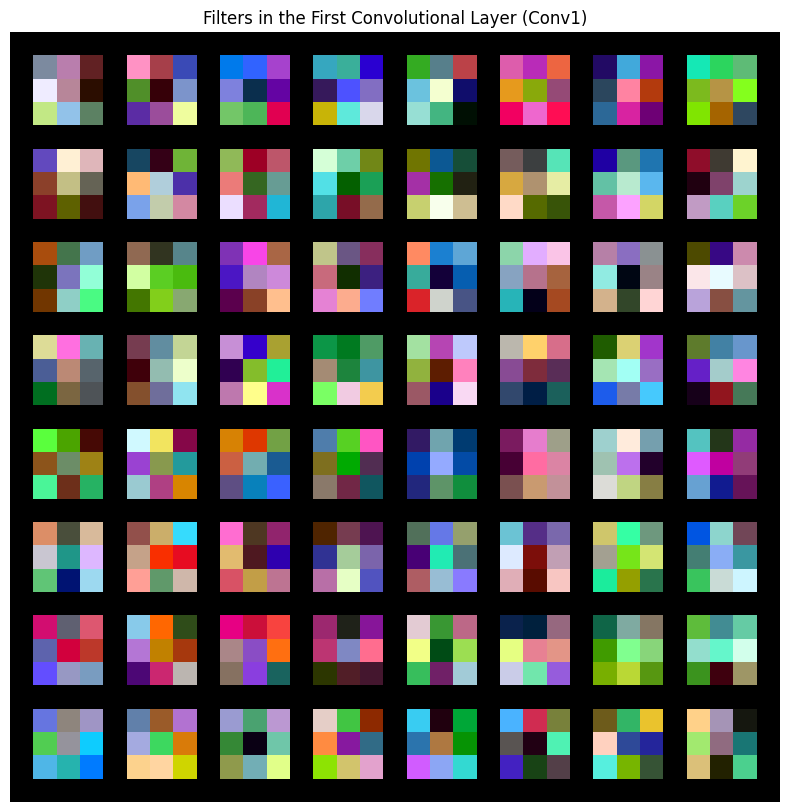

In [ ]:
import torchvision.utils as vutils

# Get the weights from the first convolutional layer
# The shape of conv1.weight is (out_channels, in_channels, kernel_height, kernel_width)
weights = net.conv1.weight.cpu().detach()

# Normalize the weights for visualization (e.g., to range [0, 1])
# This normalization is per filter channel, then across all filters.
# Min-max normalization for each filter to make it visible

# For 3-channel input filters, we can visualize them directly.
# Reshape to (out_channels, kernel_height, kernel_width, in_channels)
# Then normalize each filter independently

# Let's visualize the filters for each input channel separately, or as RGB if possible
# For simplicity, we'll average across input channels or take the first channel if not RGB

# If the input channel is 3 (RGB), we can display these directly
# If it's more or less, we might need to adjust or average

# Given `conv1 = nn.Conv2d(3, 16, 3, padding=1)`, weights shape is [16, 3, 3, 3]
# We want to display 16 filters, each as a 3x3 RGB image

fig = plt.figure(figsize=(10, 10))

# Create a grid of images for the filters
grid_img = vutils.make_grid(weights, normalize=True, scale_each=True, nrow=8, padding=1)

# Adjust the dimensions for matplotlib (from C, H, W to H, W, C)
plt.imshow(grid_img.permute(1, 2, 0))
plt.title('Filters in the First Convolutional Layer (Conv1)')
plt.axis('off')
plt.show()


#Dropout p=0.3

In [ ]:
class ModifiedVGGDropout(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3,64,3, padding=1)
    self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
    self.pool = nn.MaxPool2d(2,2)
    self.conv3 = nn.Conv2d(128,256,3,padding=1)
    self.conv4 = nn.Conv2d(256,512,3, padding=1)
    self.fc1 = nn.Linear(512*8*8, 41)
    self.fc2 = nn.Linear(41,41)
    self.fc3 = nn.Linear(41,10)
    self.dropout = nn.Dropout(p = 0.3)

  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = self.pool(x)
    x = F.relu(self.conv3(x))
    x = F.relu(self.conv4(x))
    x = self.pool(x)
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    return x

In [ ]:
net  = ModifiedVGGDropout().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [ ]:
epochs = 30
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.7171, Validation Accuracy: 23.34, Validation Loss: 13.568125780778951
Epoch: 1, Loss: 2.3558, Validation Accuracy: 38.66, Validation Loss: 11.764117286228144
Epoch: 2, Loss: 2.0083, Validation Accuracy: 44.99, Validation Loss: 10.028559009107157
Epoch: 3, Loss: 1.8378, Validation Accuracy: 48.21, Validation Loss: 9.177294478629724
Epoch: 4, Loss: 1.6792, Validation Accuracy: 52.8, Validation Loss: 8.385103494024124
Epoch: 5, Loss: 1.5384, Validation Accuracy: 56.06, Validation Loss: 7.681963648468542
Epoch: 6, Loss: 1.3988, Validation Accuracy: 59.59, Validation Loss: 6.984908792538384
Epoch: 7, Loss: 1.2945, Validation Accuracy: 61.8, Validation Loss: 6.464462798719589
Epoch: 8, Loss: 1.2036, Validation Accuracy: 63.21, Validation Loss: 6.0104980212621415
Epoch: 9, Loss: 1.1244, Validation Accuracy: 64.26, Validation Loss: 5.6146315561887175
Epoch: 10, Loss: 1.0419, Validation Accuracy: 65.47, Validation Loss: 5.202697817890789
Epoch: 11, Loss: 0.9674, Validation Acc

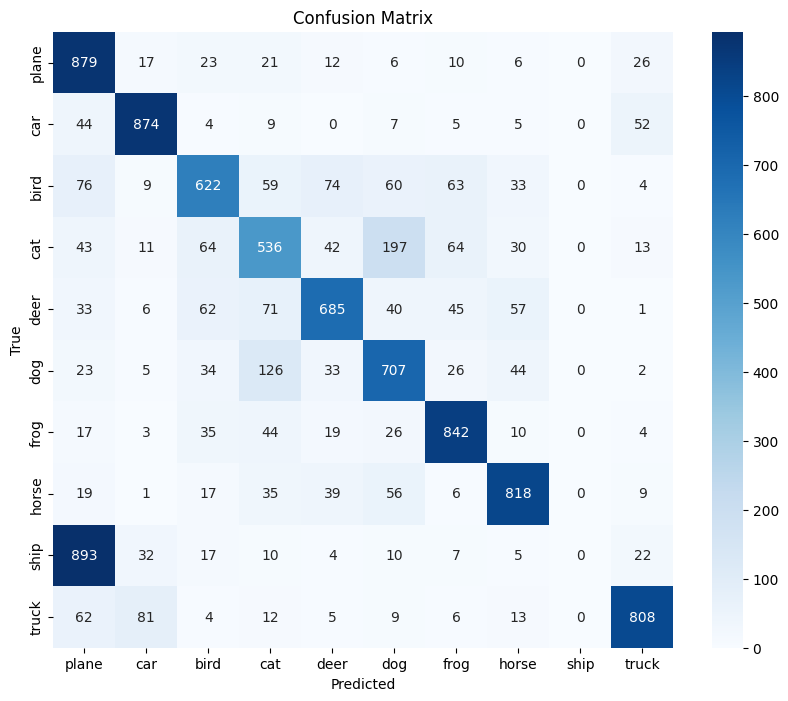

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Set the model to evaluation mode
net.eval()

all_labels = []
all_predictions = []

# Iterate over the test dataset to get all predictions
with torch.no_grad():
    for images, labels in test_loader:
        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Convert to DataFrame for better visualization with seaborn
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

dropout gives same results as alexnet at p=0.3

#Dropout p=0.5


In [ ]:
class ModifiedVGGDropout(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3,64,3, padding=1)
    self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
    self.pool = nn.MaxPool2d(2,2)
    self.conv3 = nn.Conv2d(128,256,3,padding=1)
    self.conv4 = nn.Conv2d(256,512,3, padding=1)
    self.fc1 = nn.Linear(512*8*8, 41)
    self.fc2 = nn.Linear(41,41)
    self.fc3 = nn.Linear(41,10)
    self.dropout = nn.Dropout(p = 0.5)

  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    x = self.pool(x)
    x = F.relu(self.conv3(x))
    x = F.relu(self.conv4(x))
    x = self.pool(x)
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    return x

In [ ]:
net  = ModifiedVGGDropout().to(device)
loss = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum = 0.9)

In [ ]:
epochs = 30
#Lists for storing loss and validation values
train_loss_list = []
val_loss_list = []
val_accuracy_list = []
for epoch in range(epochs):
  running_loss = 0.0
  net.train()
  for i, data in enumerate(train_loader):
    inputs, labels = data
    inputs = inputs.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = net(inputs)

    loss_function = loss(outputs, labels)
    loss_function.backward()
    optimizer.step()

    running_loss += loss_function.item()

  correct = 0
  total = 0

  net.eval()
  with torch.no_grad():
    for data in test_loader:
      images, labels = data
      images = images.to(device)
      labels = labels.to(device)
      outputs = net(images)
      loss_function = loss(outputs, labels)
      running_loss += loss_function.item()
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  val_loss = running_loss / len(test_loader)
  val_loss_list.append(val_loss)
  val_accuracy = 100 * correct / total
  val_accuracy_list.append(val_accuracy)

  train_loss_list.append(running_loss/len(train_loader))
  print(f'Epoch: {epoch}, Loss: {running_loss / len(train_loader):.4f}, Validation Accuracy: {val_accuracy}, Validation Loss: {val_loss}')

Epoch: 0, Loss: 2.7031, Validation Accuracy: 23.21, Validation Loss: 13.498391863256217
Epoch: 1, Loss: 2.4523, Validation Accuracy: 36.27, Validation Loss: 12.245737251382286
Epoch: 2, Loss: 2.1131, Validation Accuracy: 43.67, Validation Loss: 10.551777164395244
Epoch: 3, Loss: 1.7247, Validation Accuracy: 51.65, Validation Loss: 8.612703548452725
Epoch: 4, Loss: 1.5280, Validation Accuracy: 57.15, Validation Loss: 7.630164370178796
Epoch: 5, Loss: 1.3348, Validation Accuracy: 62.75, Validation Loss: 6.665221599344248
Epoch: 6, Loss: 1.1804, Validation Accuracy: 65.42, Validation Loss: 5.894234896848758
Epoch: 7, Loss: 1.0611, Validation Accuracy: 68.37, Validation Loss: 5.298912628961447
Epoch: 8, Loss: 0.9671, Validation Accuracy: 68.88, Validation Loss: 4.829382806159437
Epoch: 9, Loss: 0.8686, Validation Accuracy: 71.94, Validation Loss: 4.337476261507589
Epoch: 10, Loss: 0.7904, Validation Accuracy: 72.64, Validation Loss: 3.9467914449140284
Epoch: 11, Loss: 0.7043, Validation Ac

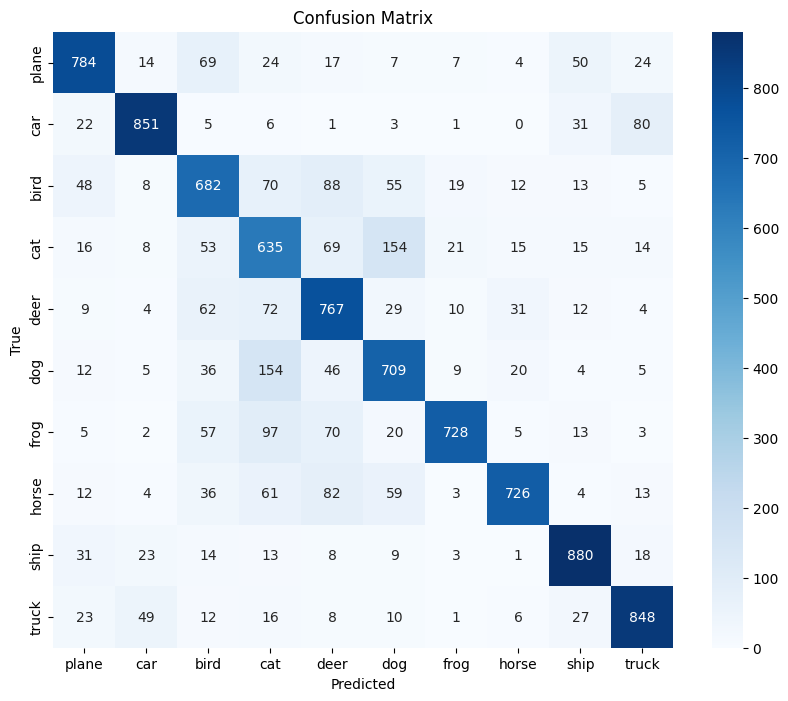

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# Set the model to evaluation mode
net.eval()

all_labels = []
all_predictions = []

# Iterate over the test dataset to get all predictions
with torch.no_grad():
    for images, labels in test_loader:
        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Convert to DataFrame for better visualization with seaborn
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

approximately 7% better than alexnet